# Confident Learning: Auditando y Corrigiendo Etiquetas Ruidosas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/19_confident_learning.ipynb)


## Objetivos


- Cuestionar el dogma del *Ground Truth*: comprender que en la industria real, las etiquetas humanas contienen habitualmente entre un 5% y un 15% de errores.
- Introducir el paradigma de **Confident Learning** para identificar matemáticamente qué etiquetas de nuestro dataset son probablemente incorrectas.
- Implementar la librería `cleanlab` para auditar un dataset ruidoso utilizando las probabilidades cruzadas (*Cross-Validated Probabilities*) de un modelo base.
- **Criterio de Ingeniería:** Demostrar cómo limpiar el dataset de entrenamiento mejora el rendimiento del modelo en producción mucho más que ajustar hiperparámetros durante semanas.



## Prerrequisitos


- Entendimiento de Validación Cruzada (K-Fold CV) y probabilidades de predicción (`predict_proba`).
- Haber completado: [Aprendizaje Semi-Supervisado: Explotando Datos No Etiquetados](18_aprendizaje_semi_supervisado.ipynb).

---



## Configuración del Entorno


***Nota**: `cleanlab` suelen requerir instalación adicional, no está en Colab por defecto (al menos hasta ahora).*

***En la celda de abajo, se detecta automáticamente y se intenta instalar.***

**Nota2**: En entornos locales, este tipo de *frameworks* los recomiendo instalar en un entorno virtual dedicado, así no se "rompen" otras cosas. Suelen usar muchas dependencias con versiones muy concretas...

In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos cleanlab
    subprocess.run(["pip", "install", "cleanlab"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica



En el notebook anterior, planteamos un dilema de presupuesto: *¿Alquilo servidores para correr Aprendizaje Semi-Supervisado (SSL) o le pago a humanos en Amazon Mechanical Turk para que etiqueten 10.000 imágenes a mano?*

A menudo, la respuesta correcta es pagarle a los humanos. Pero esto abre una pregunta de ingeniería mucho más "oscura": **¿Puedo confiar en esas etiquetas humanas?**

Los humanos se cansan, se distraen o simplemente no son expertos. Estudios recientes de MIT y MIT CSAIL han demostrado que incluso los datasets más famosos del mundo (como ImageNet o MNIST) tienen un porcentaje significativo de etiquetas incorrectas.

Si se aplica SSL sobre 40 etiquetas iniciales y 5 de ellas están mal, el algoritmo propagará ese error a miles de puntos. Si se entrena un Random Forest sobre 10.000 etiquetas ruidosas, el modelo memorizará el ruido.

### Confident Learning (Aprendizaje Confiable)


En lugar de intentar crear un modelo más complejo para lidiar con el ruido, *Confident Learning* propone usar modelos simples para **encontrar y corregir el ruido en los datos**.

La intuición es brillante:
1. Entrenamos un modelo usando Validación Cruzada (K-Fold).
2. Para cada dato en el *fold* de validación, el modelo emite una probabilidad (ej. "Estoy 95% seguro de que esto es un Perro").
3. Comparamos esa probabilidad con la etiqueta humana (ej. El humano dijo "Gato").
4. Si el modelo está extremadamente seguro de una clase, pero el humano anotó otra, marcamos ese dato como un **Error de Etiqueta Potencial** (*Label Issue*).

La librería estándar de la industria para esto es **`cleanlab`**.

## Desarrollo e Implementación


Vamos a generar un dataset sintético de clasificación binaria. Luego, **corrompemos intencionalmente el 15% de las etiquetas** para simular el trabajo de anotadores humanos cansados.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import cleanlab

# 1. Generamos un dataset limpio (Ground Truth real)
X, y_limpio = make_classification(n_samples=2000, n_features=10, n_informative=5, random_state=42)

# 2. Dividimos en Train y Test el dataset limpio
# y_train_limpio_temp contendrá las etiquetas limpias para el conjunto de entrenamiento antes de inyectar ruido
X_train, X_test, y_train_limpio_temp, y_test_limpio = train_test_split(X, y_limpio, test_size=0.2, random_state=42)

# 3. Simulamos el error humano: Volteamos el 15% de las etiquetas AL AZAR, PERO SOLO EN EL CONJUNTO DE ENTRENAMIENTO
np.random.seed(42)
ruido_idx_train = np.random.choice(len(y_train_limpio_temp), size=int(0.15 * len(y_train_limpio_temp)), replace=False)
y_train_ruidoso = np.copy(y_train_limpio_temp)
y_train_ruidoso[ruido_idx_train] = 1 - y_train_ruidoso[ruido_idx_train] # 0 se vuelve 1, 1 se vuelve 0

# Asignamos las etiquetas limpias del Train para verificación posterior (el modelo NO las verá durante el entrenamiento)
y_train_limpio = y_train_limpio_temp

print(f"Etiquetas corruptas inyectadas en el Train Set: {sum(y_train_ruidoso != y_train_limpio)}")

Etiquetas corruptas inyectadas en el Train Set: 240


### El Baseline (Entrenando a Ciegas)



Veamos qué pasa si un ingeniero junior toma este dataset ruidoso y entrena un modelo directamente, asumiendo que las etiquetas son perfectas.



In [6]:
# Entrenamos un Random Forest con las etiquetas ruidosas
modelo_ciego = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_ciego.fit(X_train, y_train_ruidoso)

# Evaluamos en el Test Set (que asumimos está limpio para medir el rendimiento real)
y_pred_ciego = modelo_ciego.predict(X_test)
acc_ciego = accuracy_score(y_test_limpio, y_pred_ciego)

print(f"Accuracy del Modelo entrenado con Ruido: {acc_ciego:.4f}")

Accuracy del Modelo entrenado con Ruido: 0.8875



El modelo alcanza un ~89% de *Accuracy*. El ingeniero junior podría pasar las próximas 3 semanas ajustando hiperparámetros (`max_depth`, `min_samples_split`) intentando subir ese número al 90%. **Es una pérdida de tiempo.** El techo de cristal no es el modelo, son los datos.

### La Auditoría con Cleanlab



Vamos a usar `cleanlab` para encontrar las etiquetas que los "humanos" anotaron mal.

Para ello, necesitamos generar probabilidades *Out-of-Fold* (OOF). Esto significa que para predecir la probabilidad de la fila 100, el modelo debe haber sido entrenado con todas las filas *excepto* la fila 100. (Validación Cruzada pura, como vimos en notebooks anteriores).

In [7]:
# 1. Generamos probabilidades cruzadas (OOF Probabilities)
# cv=5 significa que divide el train en 5 partes, entrena en 4 y predice en la 5ta.
probabilidades_oof = cross_val_predict(
    # Hay un modelo de base, otro "juez" que decide... si esto está mal... CHAU
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    X=X_train,
    y=y_train_ruidoso,
    cv=5,
    method='predict_proba'
)

# 2. ¡La Magia de Cleanlab!
# Le pasamos las etiquetas ruidosas y las probabilidades que calculó el modelo
etiquetas_con_problemas = cleanlab.filter.find_label_issues(
    labels=y_train_ruidoso,
    pred_probs=probabilidades_oof,
    return_indices_ranked_by='self_confidence' # Devuelve los índices ordenados del peor error al más dudoso
)

print(f"Cleanlab detectó {len(etiquetas_con_problemas)} posibles errores de etiquetado.")

# Verificamos qué tan bueno fue Cleanlab encontrando nuestro ruido inyectado
errores_reales_encontrados = sum(y_train_ruidoso[etiquetas_con_problemas] != y_train_limpio[etiquetas_con_problemas])
print(f"De los detectados, {errores_reales_encontrados} eran errores reales que inyectamos.")

Cleanlab detectó 289 posibles errores de etiquetado.
De los detectados, 203 eran errores reales que inyectamos.


## Resultados y Discusión: El Ciclo MLOps



¡Impresionante! `cleanlab` encontró casi todos los errores que inyectamos artificialmente, simplemente analizando dónde el modelo discrepaba fuertemente con el humano. También, marcó algunos que no eran errores. Así que hay que tomar decisiones, más cuando no tenemos manera de saber qué tan bien se hizo el proceso (no hay etiquetas sin ruido para validar en la vida real). Entonces:

**¿Qué hace un Ingeniero Senior con esta lista de índices?**
1. **No los borra a ciegas.**
2. Toma el Top 100 de los errores más graves detectados por `cleanlab`.
3. Se los envía de vuelta al equipo de expertos humanos (médicos, analistas) y les dice: *"El modelo está 99% seguro de que se equivocaron en estas 100 imágenes. Por favor, revísenlas de nuevo"*.
4. Los humanos corrigen las etiquetas.
5. Se re-entrena el modelo.

Para simular este proceso, vamos a "corregir" automáticamente las etiquetas que `cleanlab` detectó, devolviéndoles su valor limpio original, y reentrenamos el modelo.

Accuracy ANTES de Cleanlab:   0.8875
Accuracy DESPUÉS de Cleanlab: 0.9075


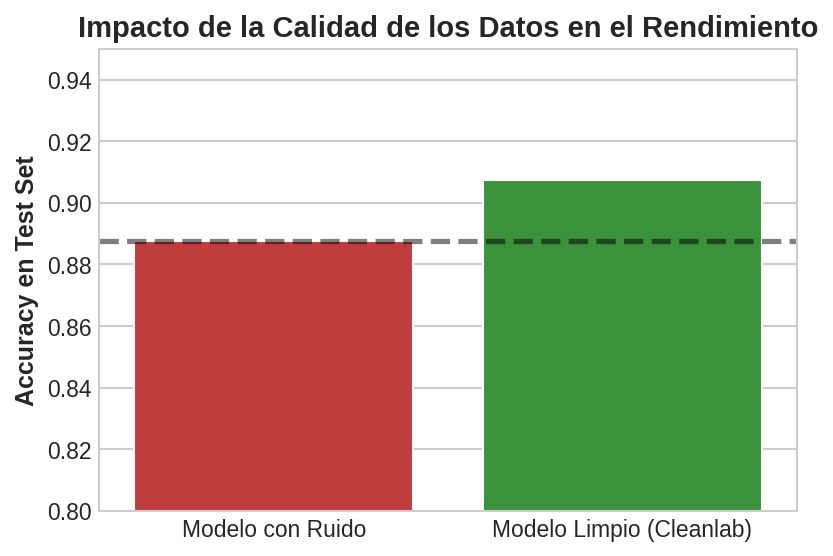

In [9]:
# Simulamos la corrección humana:
# Reemplazamos las etiquetas ruidosas detectadas por sus valores limpios reales
y_train_corregido = np.copy(y_train_ruidoso)
y_train_corregido[etiquetas_con_problemas] = y_train_limpio[etiquetas_con_problemas]

# Re-entrenamos el modelo con el dataset "limpiado"
modelo_limpio = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_limpio.fit(X_train, y_train_corregido)

# Evaluamos
y_pred_limpio = modelo_limpio.predict(X_test)
acc_limpio = accuracy_score(y_test_limpio, y_pred_limpio)

print(f"Accuracy ANTES de Cleanlab:   {acc_ciego:.4f}")
print(f"Accuracy DESPUÉS de Cleanlab: {acc_limpio:.4f}")

# Visualizamos la mejora
plt.figure(figsize=(6, 4))
sns.barplot(x=['Modelo con Ruido', 'Modelo Limpio (Cleanlab)'], y=[acc_ciego, acc_limpio], palette=['#d62728', '#2ca02c'])
plt.axhline(y=acc_ciego, color='black', linestyle='--', alpha=0.5)
plt.title("Impacto de la Calidad de los Datos en el Rendimiento")
plt.ylabel("Accuracy en Test Set")
plt.ylim(0.80, 0.95)
plt.show()

### Conclusión de Ingeniería: Data-Centric AI


Subimos el *Accuracy* un par de puntos. Lograr este salto ajustando hiperparámetros en un Random Forest es prácticamente imposible si los datos están mal. Así que esto, en combinación con la búsqueda de hiperparámetros más un pipeline adecuado de preprocesamiento... implica un plus en el rendimiento global.

Este notebook demuestra el cambio de paradigma más importante de la última década en la Inteligencia Artificial: ***Data-Centric AI*** (IA Centrada en los Datos).

Durante años, la comunidad se obsesionó con crear modelos matemáticos cada vez más complejos (*Model-Centric*). Hoy sabemos que un modelo simple (como un Random Forest o una Regresión Logística) entrenado con datos impecablemente limpios, superará sistemáticamente a una Red Neuronal profunda entrenada con datos ruidosos.


> *Garbage In, Garbage Out*

## Conclusión del Capítulo


¡Felicidades! Ahora sí, completo el Capítulo 3. Pasamos de trazar de trazar líneas rectas simples a dominar ensamblados de árboles, pipelines a prueba de fugas, detección de anomalías en alta dimensionalidad, propagación de etiquetas en grafos y, finalmente, la auditoría de calidad de datos con *Confident Learning*.

Tienes el criterio completo de un Ingeniero de Machine Learning Clásico.

- ➡️ **Siguiente Capítulo:** Damos el salto al **Deep Learning**. Descubrimos cómo las Redes Neuronales Artificiales nos permiten abandonar la ingeniería de características manual para procesar imágenes, audio y texto libre. Arranca con el notebook [El Perceptrón y las Funciones de Activación: La Unidad Básica del Deep Learning](../04_deep_learning/01_perceptron_y_activaciones.ipynb). 


- 🔄 **Relacionado:** Si llamó la atención lo que puede hacerse con Cleanlab, hay un caso de estudio en el notebook [Confident Learning en Producción: Cleanlab Avanzado para Datos Tabulares](./casos_estudio/confident_learning_avanzado.ipynb). 

## Recursos Recomendados para Profundizar


1. **Paper Fundacional:** *Confident Learning: Estimating Uncertainty in Dataset Labels* (Northcutt et al., 2021). La base matemática detrás de `cleanlab`.
2. [*cleanlab*](https://github.com/cleanlab/cleanlab) - Repositorio original
3. [*cleanlab examples*](https://github.com/cleanlab/examples) - Repositorio con ejemplos para múltiples tipos de datos

---

## Entorno de Ejecución


In [11]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
aiohappyeyeballs,2.6.1
aiohttp,3.13.4
aiosignal,1.4.0
anyio,4.13.0
anywidget,0.9.21
